# Multiple explanations of your data with `pounce.curve_fit_minima`

`pounce.curve_fit` returns **one** best-fit parameter set — whichever local
optimum the optimizer reaches from your `p0`. But a nonlinear model is often
**non-convex in its parameters**: several genuinely different parameter sets can
each explain the data, and which one `curve_fit` lands on depends entirely on
the starting guess.

`pounce.curve_fit_minima` finds *all* of them. It drives `pounce.find_minima`
over the **same fitting objective** as `curve_fit` (identical `sigma` weighting,
robust `loss`, `f_scale`, bounds, and constraints), then refines each distinct
basin into a full `CurveFitResult` — covariance, standard errors, and
confidence intervals included.


## A model that is *wrong on purpose*

Nothing exposes multiplicity like a misspecified model. Our data has **two**
bumps (a tall one near $x=3$, a shorter one near $x=7$), but we fit a **single**
Gaussian

$$g(x) = A\,\exp\!\Big(-\frac{(x-\mu)^2}{2\sigma^2}\Big).$$

A single Gaussian cannot fit both peaks at once, so the fitting landscape has
several basins — lock onto the tall peak, lock onto the short one, or
compromise in the middle.


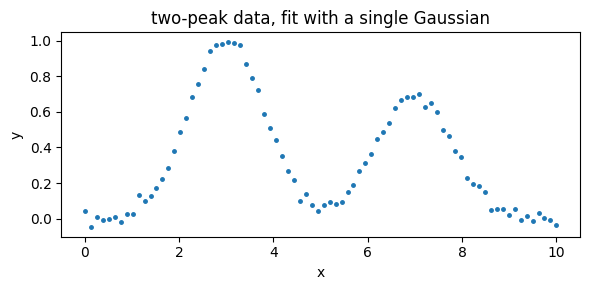

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pounce

rng = np.random.default_rng(3)
x = np.linspace(0, 10, 80)
y = (1.0 * np.exp(-(x - 3) ** 2 / (2 * 0.8 ** 2))
     + 0.7 * np.exp(-(x - 7) ** 2 / (2 * 0.8 ** 2))
     + 0.02 * rng.standard_normal(80))

# A JAX-traceable model -> exact derivatives (accurate covariance + sensitivity).
def gauss(x, A, mu, sig):
    return A * jnp.exp(-(x - mu) ** 2 / (2 * sig ** 2))

plt.figure(figsize=(6, 3))
plt.plot(x, y, ".", ms=5)
plt.title("two-peak data, fit with a single Gaussian")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout()

## Find every fit

`curve_fit_minima` has the same `(f, xdata, ydata, p0)` front as `curve_fit`,
plus the search controls from `find_minima` (`method`, `n_minima`, `max_solves`,
`dedup`, `seed`). It returns a **list of `CurveFitResult`** — one per distinct
minimum.


In [2]:
results = pounce.curve_fit_minima(
    gauss, x, y,
    p0=[0.5, 5.0, 1.0],
    bounds=([0, 0, 0.1], [2, 10, 3]),
    n_minima=5,
    seed=0,
)
results = sorted(results, key=lambda r: float(r.popt[1]))  # order by peak center
print(f"found {len(results)} distinct fits\n")
for i, r in enumerate(results):
    A, mu, sig = np.asarray(r.popt)
    print(f"  fit {i}:  A={A:.3f}  mu={mu:.3f}  sig={sig:.3f}   R^2={float(r.r_squared):+.3f}")

found 3 distinct fits

  fit 0:  A=1.003  mu=3.006  sig=0.807   R^2=+0.307
  fit 1:  A=0.534  mu=4.230  sig=2.829   R^2=+0.271
  fit 2:  A=0.681  mu=6.969  sig=0.838   R^2=-0.448


Each of those is a *real* local optimum of the least-squares objective. The
tall-peak fit and the short-peak fit are equally valid stationary points — a
single `curve_fit` call would have reported only the one nearest its `p0` and
silently hidden the rest.


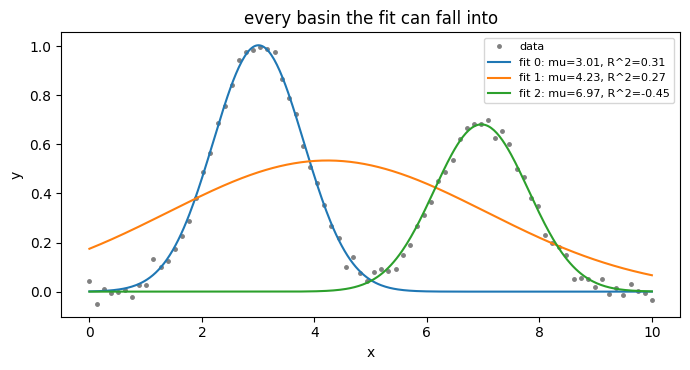

In [3]:
xx = np.linspace(0, 10, 400)
plt.figure(figsize=(7, 3.8))
plt.plot(x, y, ".", color="0.5", ms=5, label="data")
for i, r in enumerate(results):
    plt.plot(xx, np.asarray(r.predict(xx)),
             label=f"fit {i}: mu={float(r.popt[1]):.2f}, R^2={float(r.r_squared):.2f}")
plt.legend(loc="upper right", fontsize=8)
plt.title("every basin the fit can fall into")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout()

## Each result is a full `CurveFitResult`

Every entry carries the same diagnostics as a single `curve_fit` solve, so you
can quantify each explanation — parameter uncertainties, confidence intervals,
goodness of fit:


In [4]:
best = max(results, key=lambda r: float(r.r_squared))
print("best fit by R^2:")
for name, val, err in zip(best.param_names, np.asarray(best.popt), np.asarray(best.perr)):
    print(f"  {name:>3} = {val:8.4f}  +/- {err:.4f}")
print(f"  R^2 = {float(best.r_squared):.4f}   reduced chi^2 = {float(best.reduced_chi_square):.4f}")
print(f"  {int((1 - best.alpha) * 100)}% CI on mu: [{best.ci[1][0]:.3f}, {best.ci[1][1]:.3f}]")

best fit by R^2:
    A =   1.0032  +/- 0.0969
   mu =   3.0059  +/- 0.0900
  sig =   0.8070  +/- 0.0900
  R^2 = 0.3069   reduced chi^2 = 0.0707
  95% CI on mu: [2.827, 3.185]


## Why not just call `curve_fit` from a few guesses?

You can — and `curve_fit_minima` is essentially that done *well*: it reuses the
model Jacobian as the search gradient, applies a deflation/restart strategy so
restarts don't re-discover the same basin, **dedups** near-identical optima, and
refines each survivor into a fully-characterized result. The knobs:

| argument | meaning |
|---|---|
| `method` | `find_minima` strategy: `"deflation"` (default), `"restart"`, `"hopping"` |
| `n_minima` | how many distinct minima to aim for |
| `max_solves` | hard cap on solver calls (default `8 * n_minima`) |
| `dedup` | tolerance for merging near-identical optima |
| `seed` | reproducible sampling of restarts |

Everything else — `sigma`, `absolute_sigma`, `loss`, `f_scale`, `bounds`,
`constraints`, `jac` — behaves exactly as in `pounce.curve_fit`. See
`docs/src/curve-fitting.md` and the `find_minima` notebooks (19–21).
